In [152]:
#Package
import numpy as np
import networkx as nx
from scipy.stats import qmc
import EoN
from pathlib import Path
import pickle
from scipy.stats import qmc
from pathlib import Path
from tqdm import tqdm
from pathlib import Path
import csv
import pymc as pm 
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [387]:
# PARAMETERS
N = 10000                  # network size
m = 5                      # Barabasi–Albert attachment parameter

tmax=200 
n_timepoints=200
initial_samples =500   # initial Sobol samples
#mcmc_steps = 10000            # legth of mcmc chain
sigma = 0.30             # width of R0 target distribution
n_replicates=2  # replicates of parameter sets 
PARAM_RANGES = {
    'tau'  : (0.0024, 0.05),
    'gamma': (0.07, 0.5),
    'rho'  : (0.001, 0.010),
}


PARAM_NAMES = ['tau', 'gamma', 'rho']
output_path = Path('epidemic_data_age_adaptive_sobol.pkl')



In [ ]:
# Generate the mean ratio for BA-graph

results_k_avg=[]
results_k2_avg=[]
results_ratio=[]

seed = 4849
for i in range(10000) :
     G = nx.barabasi_albert_graph(N, m,seed=seed)
     degrees = np.array([d for _, d in G.degree()])
     k_avg  = degrees.mean()
     k2_avg = (degrees ** 2).mean()
     idx_ratio= (degrees ** 2).mean()/ degrees.mean() #  <k²>/<k> for BA network
    
     results_k_avg.append(k_avg)
     results_k2_avg.append(k2_avg)
     results_ratio.append(idx_ratio)

     mean_k_avg=np.mean(results_k_avg)
     mean_k2_avg=np.mean(results_k2_avg)
     ratio=np.mean(results_ratio)


print(f"Mean of <k> over 1000 BA network: {mean_k_avg}")
print(f"Mean of <k²> over 1000 BA network: {mean_k2_avg}")
print(f"Mean of <k²>/<k> over 1000 BA network: {ratio}")

net_stats = {
    'k_avg': mean_k_avg,
    'k2_avg': mean_k2_avg,
    'ratio': ratio,
    'k_std': 1.5,
    'k_max': 20
}


Mean of <k> over 1000 BA network: 9.995
Mean of <k²> over 1000 BA network: 272.53503366
Mean of <k²>/<k> over 1000 BA network: 27.267136934467235


In [ ]:
ratio=27.267136934467235 # calculated for 10000 graphs

In [315]:
# R0 COMPUTATION
def compute_R0(samples,ratio):
    """
    Compute epidemic reproduction number.

    R0 = (tau/gamma) * <k²>/<k>
    """

    tau = samples[:, 0]
    gamma = samples[:, 1]

    R0 = (tau/gamma) * ratio  

    return R0

In [388]:
# Using MCMC to sample from the target distribution  with Uniform distribution

#thinning    = int(mcmc_steps / initial_samples) 

with pm.Model() as model:
    
    # Priors: Uniform over plausible ranges
    tau   = pm.Uniform("tau", lower=PARAM_RANGES['tau'][0], upper=PARAM_RANGES['tau'][1])
    gamma = pm.Uniform("gamma", lower=PARAM_RANGES['gamma'][0], upper=PARAM_RANGES['gamma'][1])
    rho   = pm.Uniform("rho", lower=PARAM_RANGES['rho'][0], upper=PARAM_RANGES['rho'][1])

    # Compute R0 deterministically
    R0 = pm.Deterministic("R0", (tau / gamma) * ratio)
    
    # Target density: Gaussian around R0 ≈ 1
    logp = -0.5 * ((R0 - 1.0) / sigma) ** 2
    pm.Potential("R0_target", logp)
    
    # Sample with NUTS
   
    trace = pm.sample(
        draws=initial_samples,
        tune=2000, # thinning,
        chains=5,  # thus Total_sample=samples*chains
        cores=1,
        target_accept=0.95,
        random_seed=42
    )

# Convert trace to (n_samples, 3) array: tau, gamma, rho
posterior_samples = np.vstack([
    trace.posterior['tau'].values.flatten(),
    trace.posterior['gamma'].values.flatten(),
    trace.posterior['rho'].values.flatten()
]).T



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (5 chains in 1 job)
NUTS: [tau, gamma, rho]


Sampling 5 chains for 2_000 tune and 500 draw iterations (10_000 + 2_500 draws total) took 184 seconds.


In [389]:
az.summary(trace, var_names=["tau", "gamma", "rho"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.012,0.006,0.003,0.022,0.000,0.000,780.0,678.0,1.0
gamma,0.338,0.111,0.141,0.500,0.004,0.002,833.0,911.0,1.0
rho,0.005,0.003,0.002,0.010,0.000,0.000,1309.0,1242.0,1.0


| Metric          | Meaning                      |
| --------------- | ---------------------------- |
| mean            | Posterior mean estimate      |
| sd              | Posterior standard deviation |
| hdi_3%, hdi_97% | 94% Highest Density Interval |
| mcse_mean       | Monte Carlo error of mean    |
| mcse_sd         | Monte Carlo error of sd      |
| ess_bulk        | Effective sample size (bulk) |
| ess_tail        | Effective sample size (tail) |
| r_hat           | Convergence diagnostic       |


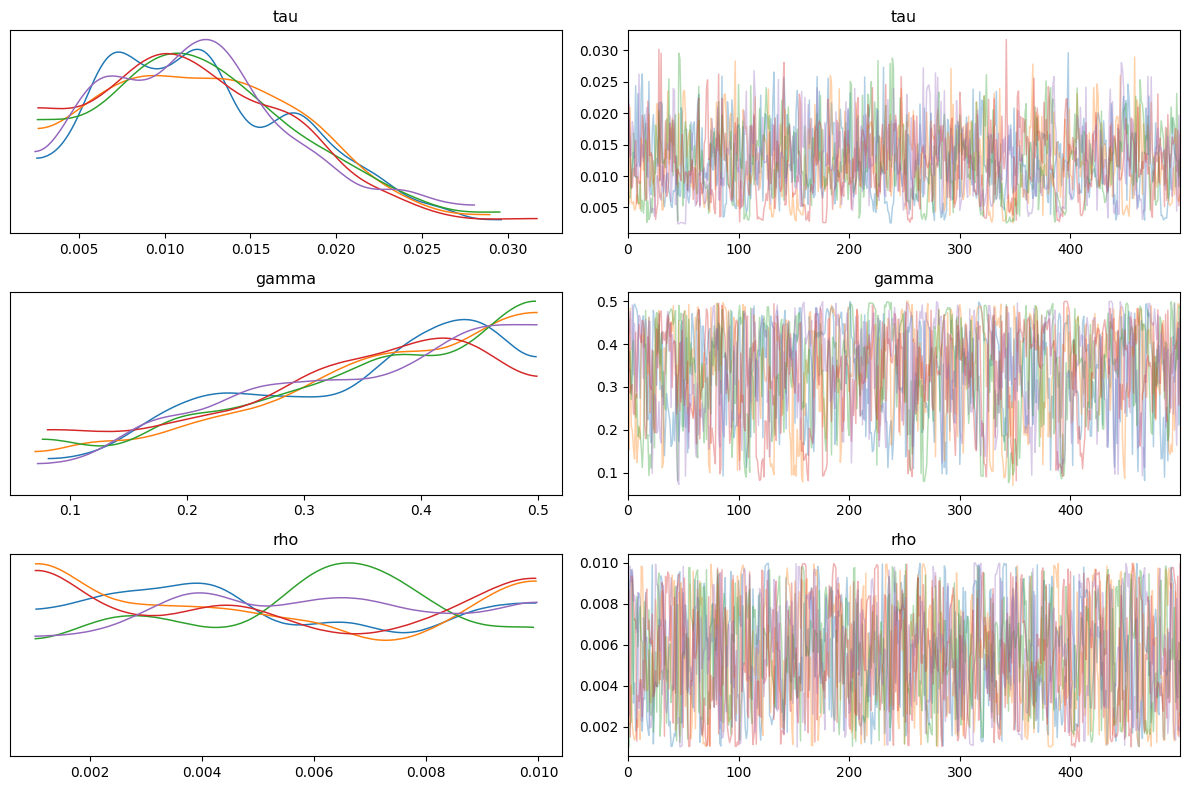

In [ ]:
az.plot_trace(
    trace,
    var_names=["tau", "gamma", "rho"],
    compact=False,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [ ]:
# #SOBOL INITIALIZATION FOR MCMC
# sampler = qmc.Sobol(d=3, scramble=True)

# lower = [v[0] for v in PARAM_RANGES.values()]
# upper = [v[1] for v in PARAM_RANGES.values()]

# sobol_points = qmc.scale(sampler.random(2), lower, upper)  # 5for 5

# initvals = [
#     {"tau": sobol_points[0,0], "gamma": sobol_points[0,1], "rho": sobol_points[0,2]}, # initial values for 2 chains
#     {"tau": sobol_points[1,0], "gamma": sobol_points[1,1], "rho": sobol_points[1,2]}
# ]

# # initvals= [
# #     {"tau": sobol_points[i,0], "gamma": sobol_points[i,1], "rho": sobol_points[i,2]}
# #     for i in range(5)  # now matches number of chains
# # ]

# # MCMC MODEL

# with pm.Model() as model:

#     tau = pm.Uniform("tau",
#                      lower=PARAM_RANGES['tau'][0],
#                      upper=PARAM_RANGES['tau'][1])

#     gamma = pm.Uniform("gamma",
#                        lower=PARAM_RANGES['gamma'][0],
#                        upper=PARAM_RANGES['gamma'][1])

#     rho = pm.Uniform("rho",
#                      lower=PARAM_RANGES['rho'][0],
#                      upper=PARAM_RANGES['rho'][1])

#     R0 = pm.Deterministic("R0", (tau/gamma) * ratio)

#     logp = -0.5 * ((R0 - 1.0)/sigma)**2

#     pm.Potential("target_density", logp)

#     trace = pm.sample(
#         draws=initial_samples,
#         tune=2000,
#         chains=2,
#         cores=1,
#         target_accept=0.95,
#         initvals=initvals,
#         random_seed=42
#     )


# # EXTRACT POSTERIOR SAMPLES

# posterior_samples = np.vstack([
#     trace.posterior['tau'].values.flatten(),
#     trace.posterior['gamma'].values.flatten(),
#     trace.posterior['rho'].values.flatten()
# ]).T

# print("Posterior samples shape:", posterior_samples.shape)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [tau, gamma, rho]


Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 41 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Posterior samples shape: (2000, 3)


In [373]:
#posterior sample dimensions 
print(posterior_samples.shape) #1000,3

(3000, 3)


In [ ]:
#  Define SIR replicates


def run_sir_replicates(G, tau, gamma, rho, n_replicates=n_replicates, tmax=tmax, n_timepoints=n_timepoints):
    t_fixed = np.linspace(0, tmax, n_timepoints)
    S_runs, I_runs, R_runs = [], [], []

    for _ in range(n_replicates):
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)
        S_runs.append(np.interp(t_fixed, t, S))
        I_runs.append(np.interp(t_fixed, t, I))
        R_runs.append(np.interp(t_fixed, t, R))

    return {
        't': t_fixed,
        'S': np.array(S_runs).mean(axis=0),
        'I': np.array(I_runs).mean(axis=0),
        'R': np.array(R_runs).mean(axis=0),
        'S_std': np.array(S_runs).std(axis=0),
        'I_std': np.array(I_runs).std(axis=0),
        'R_std': np.array(R_runs).std(axis=0),
        'n_replicates': n_replicates
    }




  



In [392]:
#Run batch of simulations

def run_batch(G, params_array, n_replicates=n_replicates, tmax=tmax, n_timepoints=n_timepoints):
    results = []
    for row in tqdm(params_array, desc=f"Running {len(params_array)} parameter sets/simulations"):  # tqdm gives a progress bar for large numbers of simulations.
        tau, gamma, rho = row
        output = run_sir_replicates(G, tau, gamma, rho, n_replicates, tmax, n_timepoints)
        results.append({'params': {'tau': tau, 'gamma': gamma, 'rho': rho}, 'output': output}) #coming from the MCMC posterior samples
    return results

# Example: G is a networkx graph

G = nx.barabasi_albert_graph(N, m)

all_sims = run_batch(G, posterior_samples)

#params_array = posterior_samples

Running 2500 parameter sets/simulations: 100%|██████████| 2500/2500 [00:26<00:00, 95.62it/s] 


In [394]:

# Build dataset

def build_dataset(all_sims, G, net_stats):
    dataset = {
        'simulations': all_sims,
        'network': {
            'type': 'barabasi_albert',
            'N': G.number_of_nodes(),
            'm': m,
            'ratio': net_stats['ratio'],
            'graph': G
        },
        'metadata': {
            'n_samples': len(all_sims),
            'n_replicates': n_replicates,
            'param_ranges': PARAM_RANGES,
            'R0_formula': 'R0 = (tau/gamma) * <k^2>/<k>',
            'sampling_strategy': 'MCMC NUTS'
        }
    }
    return dataset

dataset = build_dataset(all_sims, G, net_stats)

In [395]:

#  Save dataset (pickle)

def save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl'):
    with open(filepath, 'wb') as f:
        pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Dataset saved to {filepath}")

save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl')


#  Save CSV summary

def save_csv(dataset, filepath='epidemic_data_age_adaptive.sobol.csv'):
    sims = dataset['simulations']
    ratio = dataset['network']['ratio']
    param_fields = ['sim_id','tau','gamma','rho','R0','peak_I','peak_time','final_R','attack_rate','near_threshold']

    with open(filepath, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=param_fields)
        writer.writeheader()
        for sim_id, sim in enumerate(sims):
            tau = sim['params']['tau']
            gamma = sim['params']['gamma']
            rho = sim['params']['rho']
            R0 = (tau/gamma) * ratio
            I_traj = sim['output']['I']
            R_traj = sim['output']['R']
            t_grid = sim['output']['t']
            writer.writerow({
                'sim_id': sim_id,
                'tau': tau,
                'gamma': gamma,
                'rho': rho,
                'R0': R0,
                'peak_I': float(I_traj.max()),
                'peak_time': float(t_grid[I_traj.argmax()]),
                'final_R': float(R_traj[-1]),
                'attack_rate': float(R_traj[-1]),
                'near_threshold': int(abs(R0-1) < 0.2)
            })
    print(f"CSV saved to {filepath}")

save_csv(dataset, filepath='epidemic_data_age_adaptive_sobol.csv')

Dataset saved to epidemic_data_age_adaptive_sobol.pkl
CSV saved to epidemic_data_age_adaptive_sobol.csv


In [396]:
#Data Exploration 

data=pd.read_csv('epidemic_data_age_adaptive_sobol.csv')

print(data.columns)
print(len(data))
print(data.isnull().sum()) # no missing values
print(data.describe(include='all'))

print(ratio)


Index(['sim_id', 'tau', 'gamma', 'rho', 'R0', 'peak_I', 'peak_time', 'final_R',
       'attack_rate', 'near_threshold'],
      dtype='object')
2500
sim_id            0
tau               0
gamma             0
rho               0
R0                0
peak_I            0
peak_time         0
final_R           0
attack_rate       0
near_threshold    0
dtype: int64
           sim_id          tau        gamma          rho           R0  \
count  2500.00000  2500.000000  2500.000000  2500.000000  2500.000000   
mean   1249.50000     0.012248     0.338038     0.005466     0.990776   
std     721.83216     0.005601     0.110753     0.002612     0.295099   
min       0.00000     0.002414     0.070024     0.001009     0.141504   
25%     624.75000     0.007893     0.254064     0.003216     0.786619   
50%    1249.50000     0.011740     0.357122     0.005446     0.986846   
75%    1874.25000     0.016056     0.432755     0.007708     1.191182   
max    2499.00000     0.031739     0.499882     0.00998

In [397]:
total_samples=len(data)
print(total_samples)
greater=data[data['R0']>1.2]
pc1=(len(greater)/total_samples)*100
print(f"greater than 1,2: {len(greater),pc1}")



between = data[(data['R0'] >= 0.8) & (data['R0'] <= 1.2)]
pc2=(len(between)/total_samples)*100
print(f"between 0.8 and 1.2: {len(between),pc2}")


#print(pc2)

less_than=data[data['R0']<0.8]
pc3=(len(less_than)/total_samples)*100
print(f"less than 0.8: {len(less_than),pc3}")




2500
greater than 1,2: (602, 24.08)
between 0.8 and 1.2: (1242, 49.68)
less than 0.8: (656, 26.240000000000002)


In [ ]:
print(ratio)
slope=1/ratio
print(slope)


27.267136934467235
0.036674184106800824


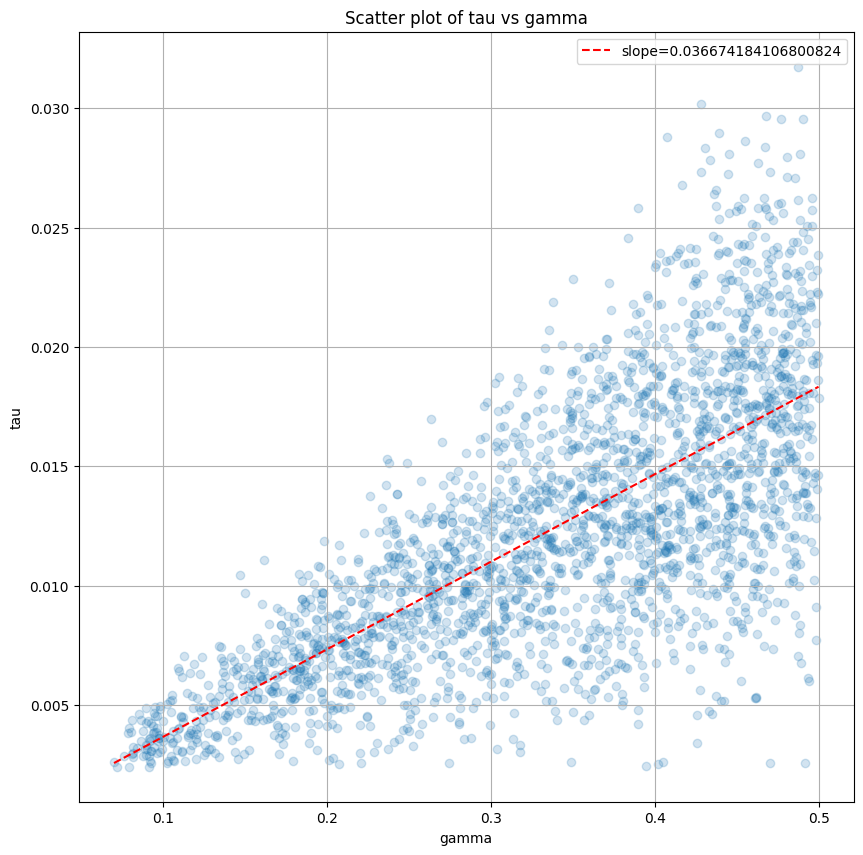

In [398]:
slope = 1/ratio

plt.figure(figsize=(10,10))
plt.scatter(data['gamma'], data['tau'], alpha=0.2)

x_vals = np.linspace(data['gamma'].min(), data['gamma'].max(), 100)
y_vals = slope * x_vals

plt.plot(x_vals, y_vals, color='red', linestyle='--', label=f'slope={slope}')

plt.xlabel('gamma')
plt.ylabel('tau')
plt.title('Scatter plot of tau vs gamma')
plt.legend()
plt.grid(True)
plt.show()